In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
import sys
import json
import wandb
import torch.nn as nn
from torch.utils.data import DataLoader

notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
print(sys.path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

%load_ext autoreload
%autoreload 2

['/mnt/ceph/users/blyo1/projects', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python310.zip', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/lib-dynload', '', '/mnt/home/blyo1/venvs/py310/lib/python3.10/site-packages']


# load the model weights

In [9]:
from b_models.configs.sami_config import SAMI_SOS_Training_Config
from utils.wandb_utils import get_wandb_run_name, get_artifact

project_name = "sami_sos"
model_num = 49

# construct config from wandb run
model_path, artifact, config, run_config = get_artifact(model_num=model_num, project_name=project_name)
config = SAMI_SOS_Training_Config.from_dict(run_config)

/mnt/home/blyo1/hdiva/c_training/lightning_checkpoints/sami_sos
wandb run name: 5sstgc0f


wandb:   1 of 1 files downloaded.  


In [10]:
from b_models.sami.sami_lightning import SAMI_Lightning
from b_models.sami.sami_inference import SAMI_Inference

lightning_model = SAMI_Lightning.load_from_checkpoint(checkpoint_path=model_path, config=config)
sami_inference = SAMI_Inference(sami=lightning_model.model, config=config).to(device)

# load the dataset

In [11]:
from a_datasets.sos.data import load_sos_data

cpu_tensor, (square_targets, circle_targets) = load_sos_data(num_samples=1000, grid_size=config.image_dim)
print(cpu_tensor.shape)
print(cpu_tensor.min(), cpu_tensor.max())
print(square_targets.shape, circle_targets.shape)

# print(config.dataset_size)

torch.Size([1000, 1, 28, 28])
tensor(0.) tensor(0.9999)
(1000,) (1000,)


In [12]:
from torchvision import transforms

from a_datasets.custom_dataset_classes import CustomTensorDataset

transform = transforms.Compose(
    [
        transforms.Normalize((0.5,), (0.5,)),
    ]
)
train_dataset = CustomTensorDataset(cpu_tensor, transform)

input_img = train_dataset[31]
print(input_img.shape)
print(input_img.min())
print(input_img.max())


torch.Size([1, 28, 28])
tensor(-1.)
tensor(0.9896)


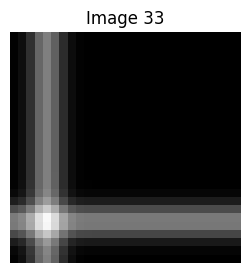

-1.0 0.9474117755889893
---
-1.0 0.9474118


In [13]:
from utils.base_utils import t2n, to_01

"""select an image from cis dataset"""
img_idx = 33
target_img = t2n(train_dataset[img_idx])
target_img = np.transpose(target_img, (1,2,0))

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(target_img, cmap='gray', vmin=-1, vmax=1)
ax.axis('off')
ax.set_title(f"Image {img_idx}")
plt.show()

print(train_dataset[img_idx].min().item(), train_dataset[img_idx].max().item())
print('---')
print(target_img.min(), target_img.max())

# conditional generation

In [14]:
"""generate images from sami_inference"""
sami_inference.conditional_sample(N=4, target_image_input=train_dataset[img_idx].unsqueeze(0), return_chain=False)
gen_img = sami_inference.x_t
print(gen_img.shape)
print(gen_img.min(), gen_img.max())

torch.Size([4, 1, 28, 28])
tensor(-1.0229, device='cuda:0', grad_fn=<MinBackward1>) tensor(0.9771, device='cuda:0', grad_fn=<MaxBackward1>)


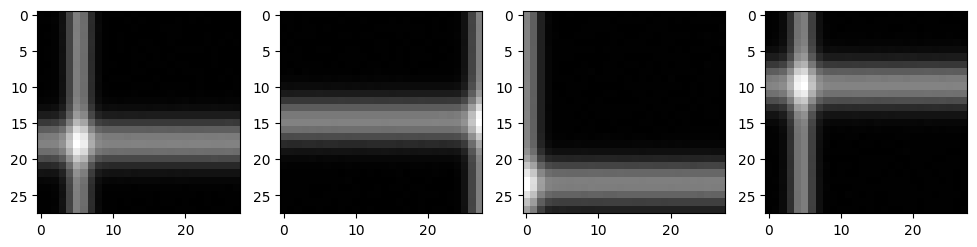

In [15]:
gen_img_np = gen_img.cpu().detach().numpy()

plots=(1, 4)
fig, ax = plt.subplots(*plots, figsize=(plots[-1]*3, 3))

for i in range(4):
    ax[i].imshow(gen_img_np[i].squeeze(), cmap='grey')